In [1]:
import os
import glob
import numpy as np
import pandas as pd
from skimage import filters, measure, morphology
from skimage.io import imread
from PIL import Image
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import ndimage as ndi

# H3K9me foci localization and average intensity

In [2]:
# -------------------------
# 1) Blue nucleus segmentation (robust to unreadable tifs)
# -------------------------
def segment_nucleus_from_blue(
    blue_path,
    sigma=1.0,
    min_nucleus_size=2000,
    hole_area=2000,
    closing_radius=8,
    opening_radius=3,
    use_otsu=True,
    fallback_percentile=80,
):
    try:
        img = np.array(Image.open(blue_path))
    except (UnidentifiedImageError, OSError) as e:
        print(f"[SKIP] Cannot read blue image: {blue_path}  ({e})")
        return None, {"thr": None, "blue_smooth": None, "blue": None, "read_error": str(e)}

    # If it's RGB, take blue channel; if grayscale, use directly
    if img.ndim == 3 and img.shape[-1] >= 3:
        blue = img[:, :, 2].astype(np.float64)
    else:
        blue = img.astype(np.float64)

    smooth = filters.gaussian(blue, sigma=sigma)

    if use_otsu:
        thr = filters.threshold_otsu(smooth)
    else:
        thr = np.percentile(smooth, fallback_percentile)

    nuc = smooth > thr

    # Morphology to clean + smooth edge
    if opening_radius and opening_radius > 0:
        nuc = morphology.binary_opening(nuc, morphology.disk(opening_radius))
    if closing_radius and closing_radius > 0:
        nuc = morphology.binary_closing(nuc, morphology.disk(closing_radius))

    nuc = morphology.remove_small_objects(nuc, min_nucleus_size)
    nuc = morphology.remove_small_holes(nuc, hole_area)

    labels = measure.label(nuc)
    if labels.max() == 0:
        return None, {"thr": float(thr), "blue_smooth": smooth, "blue": blue, "read_error": None}

    largest = max(measure.regionprops(labels), key=lambda r: r.area)
    nuc = labels == largest.label

    return nuc, {"thr": float(thr), "blue_smooth": smooth, "blue": blue, "read_error": None}


In [3]:
def mean_intensity_in_nucleus(
    green_path,
    nucleus_mask,
    sigma_green=1.0
):
    img = np.array(Image.open(green_path))

    # green channel
    if img.ndim == 3 and img.shape[-1] >= 2:
        green = img[:, :, 1].astype(np.float64)
    else:
        green = img.astype(np.float64)

    green_s = filters.gaussian(green, sigma=sigma_green)

    vals = green_s[nucleus_mask]
    if vals.size == 0:
        return None, None

    return float(vals.mean()), float(vals.sum())

In [4]:
def high_fraction_metrics_in_nucleus(
    green_path,
    nucleus_mask,
    # smoothing / denoise for high regions
    sigma_green=1.0,
    sigma_high=1.5,            # extra smoothing used ONLY to define high mask
    high_percentile=80,

    # clean high mask
    min_high_size=80,          # remove tiny islands (pixels); tune (50–300)
    high_hole_area=50,         # fill tiny holes inside high regions
    high_closing_radius=2,     # merge nearby pixels + smooth edges
    high_opening_radius=1,     # remove spurs / speckles
):
    img = np.array(Image.open(green_path))

    # if RGB-like, take green channel; else grayscale
    if img.ndim == 3 and img.shape[-1] >= 2:
        green = img[:, :, 1].astype(np.float64)
    else:
        green = img.astype(np.float64)

    # base smoothing (for intensity measurements)
    green_s = filters.gaussian(green, sigma=sigma_green)

    # stronger smoothing (ONLY for defining high mask)
    green_high = filters.gaussian(green, sigma=sigma_high)

    vals = green_high[nucleus_mask]
    if vals.size == 0:
        return None

    high_thr = np.percentile(vals, high_percentile)

    # initial high mask from smoothed image
    high_mask = nucleus_mask & (green_high >= high_thr)

    # ---- clean high mask ----
    if high_opening_radius and high_opening_radius > 0:
        high_mask = morphology.binary_opening(high_mask, morphology.disk(high_opening_radius))
    if high_closing_radius and high_closing_radius > 0:
        high_mask = morphology.binary_closing(high_mask, morphology.disk(high_closing_radius))

    if min_high_size and min_high_size > 0:
        high_mask = morphology.remove_small_objects(high_mask, min_high_size)

    if high_hole_area and high_hole_area > 0:
        high_mask = morphology.remove_small_holes(high_mask, high_hole_area)

    # centroid + nuclear radius (for radial localization)
    ys, xs = np.where(nucleus_mask)
    cy, cx = ys.mean(), xs.mean()
    boundary = morphology.binary_dilation(nucleus_mask) ^ nucleus_mask
    by, bx = np.where(boundary)
    r_nuc = np.mean(np.sqrt((by - cy)**2 + (bx - cx)**2)) + 1e-9

    # measure intensity using green_s (less aggressive smoothing)
    if high_mask.sum() == 0:
        high_loc = None
        high_sum = 0.0
        high_mean = None
        high_count = 0
    else:
        hy, hx = np.where(high_mask)
        high_int = green_s[hy, hx]
        high_rad = np.sqrt((hy - cy)**2 + (hx - cx)**2) / r_nuc

        high_loc = float(np.sum(high_rad * high_int) / (np.sum(high_int) + 1e-9))
        high_sum = float(np.sum(high_int))
        high_mean = float(np.mean(high_int))
        high_count = int(len(high_int))

    return {
        "high_thr": float(high_thr),
        "high_mask": high_mask,
        "green": green,
        "green_smooth": green_s,
        "green_high_smooth": green_high,
        "high_frac_localization": high_loc,
        "high_sum_intensity": high_sum,
        "high_mean_intensity": high_mean,
        "high_pixel_count": high_count,
        "nucleus_area": int(nucleus_mask.sum()),
    }    

In [5]:
def plot_and_measure_high_fraction_using_blue_nucleus(
    green_path,
    blue_path,
    blue_sigma=1.0,
    blue_closing_radius=8,
    blue_opening_radius=3,
    blue_min_nucleus_size=2000,
    blue_hole_area=2000,
    green_sigma=1.0,
    high_percentile=90,
    overlay_alpha=0.45,
):
    nuc_mask, nuc_dbg = segment_nucleus_from_blue(
        blue_path,
        sigma=blue_sigma,
        min_nucleus_size=blue_min_nucleus_size,
        hole_area=blue_hole_area,
        closing_radius=blue_closing_radius,
        opening_radius=blue_opening_radius,
        use_otsu=True,
    )

    if nuc_mask is None:
        print(f"[WARN] No nucleus found from blue: {blue_path}")
        return None

    out = high_fraction_metrics_in_nucleus(
        green_path,
        nuc_mask,
        sigma_green=green_sigma,
        high_percentile=high_percentile
    )
    if out is None:
        print(f"[WARN] No green values inside nucleus for: {green_path}")
        return None

    # outlines
    nuc_edge = morphology.binary_dilation(nuc_mask) ^ nuc_mask
    high_edge = morphology.binary_dilation(out["high_mask"]) ^ out["high_mask"]

    # mean nuclear intensity (ALL pixels, within blue-defined nucleus)
    nuc_mean, nuc_sum = mean_intensity_in_nucleus(
        green_path,
        nuc_mask,
        sigma_green=green_sigma
    )

    # plot
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))

    axes[0].imshow(out["green"], cmap="gray")
    axes[0].set_title("Green (raw)")
    axes[0].axis("off")

    axes[1].imshow(nuc_dbg["blue"], cmap="gray")
    axes[1].imshow(nuc_edge.astype(float), alpha=0.9)
    axes[1].set_title(f"Blue nucleus mask (Otsu thr={nuc_dbg['thr']:.2f})")
    axes[1].axis("off")

    axes[2].imshow(out["green"], cmap="gray")
    axes[2].imshow(out["high_mask"].astype(float), alpha=overlay_alpha)
    axes[2].imshow(nuc_edge.astype(float), alpha=0.9)
    axes[2].imshow(high_edge.astype(float), alpha=0.9)
    axes[2].set_title(f"High fraction only: ≥ P{high_percentile} (thr={out['high_thr']:.2f})")
    axes[2].axis("off")

    plt.tight_layout()
    plt.show()
    plt.close(fig)

    return {
        "blue_thr": float(nuc_dbg["thr"]),
        "high_thr": float(out["high_thr"]),
        "nucleus_area": int(out["nucleus_area"]),

        # whole nucleus intensity
        "nuclear_mean_intensity": nuc_mean,
        "nuclear_sum_intensity": nuc_sum,

        # high fraction metrics
        "high_pixel_count": int(out["high_pixel_count"]),
        "high_sum_intensity": float(out["high_sum_intensity"]),
        "high_mean_intensity": out["high_mean_intensity"],
        "high_frac_localization": out["high_frac_localization"],
    }

In [19]:
base_dir = "/home/xiangru.huo-umw/scHiC/scripts/hardening_image/IF/01-30-26/"
timecourses = [
    "ES", "DE", "HB", "iHep", "mHep"
]

In [ ]:
#cenpB

In [ ]:
all_results = []

for tc in timecourses:
    print(f"\n=== Processing {tc} ===")

    folders = glob.glob(os.path.join(base_dir, f"{tc}_cenpB-488*"))

    for folder in folders:
        print(f"  Folder: {folder}")

        green_images = sorted(glob.glob(os.path.join(folder, "*_ch01_SV.tif")))
        if len(green_images) == 0:
            print("    [SKIP] No green images found")
            continue

        for green_path in green_images:
            img_name = os.path.basename(green_path)
            print(f"    Processing: {img_name}")

            # infer blue channel path (nucleus)
            blue_path = green_path.replace("_ch01_", "_ch00_")
            if not os.path.exists(blue_path):
                print(f"    [SKIP] Blue channel not found: {blue_path}")
                continue

            # --------------------------------------------------
            # BLUE-defined nucleus + HIGH fraction (CenpB)
            # --------------------------------------------------
            metrics = plot_and_measure_high_fraction_using_blue_nucleus(
                green_path=green_path,
                blue_path=blue_path,
                blue_sigma=1.0,
                blue_closing_radius=10,
                blue_opening_radius=3,
                blue_min_nucleus_size=2000,
                blue_hole_area=2000,
                green_sigma=1.0,
                high_percentile=90,   # HIGH fraction only
            )

            if metrics is None:
                continue

            all_results.append({
                "timecourse": tc,
                "folder": os.path.basename(folder),
                "image": img_name,
                **metrics
            })

In [ ]:
#save results to csv
df = pd.DataFrame(all_results)

output_path = os.path.join(
    base_dir,
    "CenpB_localization_results.csv"
)

In [26]:
#reload the table
df = pd.read_csv(
    os.path.join(base_dir, "CenpB_localization_results.csv")
)

df.head()

,timecourse,folder,image,blue_thr,high_thr,nucleus_area,nuclear_mean_intensity,nuclear_sum_intensity,high_pixel_count,high_sum_intensity,high_mean_intensity,high_frac_localization
0,ES,ES_cenpB-488_K9me3-594,013026-modification_cenpB_ES-cenpB-488-H3K9m3-...,72.873793,102.481612,204050,70.782754,1.444322e+07,20049,2.601637e+06,129.763911,0.563588
1,ES,ES_cenpB-488_K9me3-594,013026-modification_cenpB_TileScan 5_P 1 (2)_c...,24.088253,86.729916,226940,63.932866,1.450892e+07,22076,2.485655e+06,112.595356,0.563968
2,ES,ES_cenpB-488_K9me3-594,013026-modification_cenpB_TileScan 5_P 2_ch01_...,44.373097,112.062840,189479,62.900052,1.191824e+07,18956,2.882913e+06,152.084485,0.641160
3,ES,ES_cenpB-488_K9me3-594,013026-modification_cenpB_TileScan 5_P 3_ch01_...,32.540271,57.050197,266244,43.988463,1.171166e+07,25596,1.992280e+06,77.835603,0.667175
4,ES,ES_cenpB-488_K9me3-594,013026-modification_cenpB_TileScan 5_P 4_ch01_...,36.766281,55.337237,242056,38.447607,9.306474e+06,23439,1.582392e+06,67.511092,0.693126


/home/xiangru.huo-umw/conda/Jupiter/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/home/xiangru.huo-umw/conda/Jupiter/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/home/xiangru.huo-umw/conda/Jupiter/lib/python3.11/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)


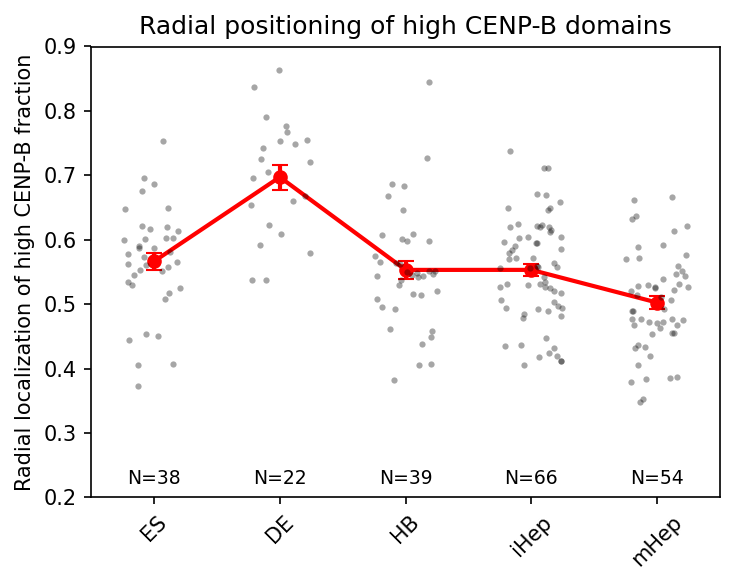

In [27]:
# plot the localization of CENP-B high fraction
df_cenpB_plot = df.copy()

# enforce biological order
timecourse_order = ["ES", "DE", "HB", "iHep", "mHep"]

# summarize mean, SD, N, SE
summary_df = (
    df_cenpB_plot
    .groupby("timecourse")["high_frac_localization"]
    .agg(["mean", "std", "count"])
    .reindex(timecourse_order)
    .reset_index()
)

summary_df["se"] = summary_df["std"] / np.sqrt(summary_df["count"])

# x positions
x = np.arange(len(timecourse_order))

plt.figure(figsize=(5, 4), dpi=150)
ax = plt.gca()

# line plot with SE
ax.errorbar(
    x,
    summary_df["mean"],
    yerr=summary_df["se"],
    fmt="-o",
    linewidth=2,
    markersize=6,
    capsize=4,
    color="red",
    ecolor="red"
)

# optional: add individual points in light gray
sns.stripplot(
    data=df_cenpB_plot,
    x="timecourse",
    y="high_frac_localization",
    order=timecourse_order,
    color="black",
    size=3,
    jitter=0.25,
    alpha=0.35,
    ax=ax
)

# reset x labels because errorbar uses numeric x
ax.set_xticks(x)
ax.set_xticklabels(timecourse_order, rotation=45)

ax.set_ylabel("Radial localization of high CENP-B fraction")
ax.set_xlabel("")
ax.set_title("Radial positioning of high CENP-B domains")

# y-axis from 0.2 to 1
ax.set_ylim(0.2, 0.9)

# Add N labels
for i, row in summary_df.iterrows():
    ax.text(
        i,
        0.215,
        f"N={int(row['count'])}",
        ha="center",
        va="bottom",
        fontsize=9
    )

plt.tight_layout()
#plt.savefig(
#    "/home/xiangru.huo-umw/scHiC/scripts/hardening_image/IF/Radial_positions_of_cenpB_domains_lineplot_SE.pdf",
#    bbox_inches="tight")
plt.show()

In [ ]:
#K27ac over 12 samples

In [39]:
base_dir = "/home/xiangru.huo-umw/scHiC/scripts/hardening_image/IF/05-28-26/K27ac-488-K9me2-594-051826/"

timecourses = [
    "H1", "DE+0","DE+1","DE+2","DE+3","DE+4","DE+5","DE+6","DE+7", "HB", "iHep", "mHep"
]

In [ ]:
import os
import glob
import numpy as np
import pandas as pd
import tifffile as tiff

all_results = []

drop_array_keys = [
    "nucleus_mask",
    "high_mask",
    "relative_radius_map",
    "green_smooth",
    "blue_smooth",
]

for tc in timecourses:
    print(f"\n=== Processing {tc} ===")

    folders = sorted(glob.glob(os.path.join(base_dir, f"{tc}*K27ac*")))
    print(f"  Found {len(folders)} folders")

    for folder in folders:
        print(f"  Folder: {folder}")

        tif_files = sorted(glob.glob(os.path.join(folder, "*_SV.tif")))

        if len(tif_files) == 0:
            print("    [SKIP] No *_SV.tif files found")
            continue

        for tif_path in tif_files:
            img_name = os.path.basename(tif_path)
            print(f"    Processing: {img_name}")

            stack = tiff.imread(tif_path)
            print("      stack shape:", stack.shape)

            # --------------------------------------------------
            # Use only:
            #   channel 0 = nucleus
            #   channel 1 = K27ac
            # --------------------------------------------------
            if stack.ndim == 4 and stack.shape[0] >= 2:
                nucleus_img = stack[0].max(axis=-1)
                K27ac_img   = stack[1].max(axis=-1)

            elif stack.ndim == 3 and stack.shape[0] >= 2:
                nucleus_img = stack[0]
                K27ac_img   = stack[1]

            else:
                print(f"      [SKIP] Unexpected TIFF shape: {stack.shape}")
                continue

            print(
                "      intensity:",
                "nucleus", nucleus_img.min(), nucleus_img.max(),
                "K27ac", K27ac_img.min(), K27ac_img.max()
            )

            # -------------------------
            # K27ac high-fraction measurement
            # -------------------------
            metrics_K27ac = plot_and_measure_high_fraction_using_blue_nucleus_from_arrays(
                green_img=K27ac_img,
                blue_img=nucleus_img,
                blue_sigma=1.0,
                blue_closing_radius=10,
                blue_opening_radius=3,
                blue_min_nucleus_size=500,
                blue_hole_area=500,
                green_sigma=1.0,
                high_percentile=90,
            )

            if metrics_K27ac is None:
                print("      [SKIP] metrics_K27ac is None")
                continue

            # -------------------------
            # K27ac whole-nucleus intensity
            # -------------------------
            nuc_mask = metrics_K27ac["nucleus_mask"].astype(bool)

            K27ac_smooth = filters.gaussian(
                K27ac_img.astype(float),
                sigma=1.0
            )

            K27ac_nuclear_mean_intensity = float(
                K27ac_smooth[nuc_mask].mean()
            )

            K27ac_nuclear_sum_intensity = float(
                K27ac_smooth[nuc_mask].sum()
            )

            # optional relative intensity normalization
            # adjust 255.0 if you want another normalization factor
            K27ac_nuclear_mean_intensity_rel = (
                K27ac_nuclear_mean_intensity / 255.0
            )

            # remove large array outputs before saving
            metrics_K27ac_clean = {
                k: v for k, v in metrics_K27ac.items()
                if k not in drop_array_keys
            }

            all_results.append({
                "timecourse": tc,
                "folder": os.path.basename(folder),
                "image": img_name,
                "n_channels": stack.shape[0],

                # whole nucleus K27ac intensity
                "K27ac_nuclear_mean_intensity": K27ac_nuclear_mean_intensity,
                "K27ac_nuclear_sum_intensity": K27ac_nuclear_sum_intensity,
                "K27ac_nuclear_mean_intensity_rel": K27ac_nuclear_mean_intensity_rel,

                # high-fraction K27ac metrics
                **{f"K27ac_{k}": v for k, v in metrics_K27ac_clean.items()},
            })

            print("      [OK] Added result")

print("\nTotal results:", len(all_results))

df_results = pd.DataFrame(all_results)
df_results.head()

In [41]:
#save results to csv
df = pd.DataFrame(all_results)

output_path = os.path.join(
    base_dir,
    "K27ac_localization_results.csv"
)

df.to_csv(output_path, index=False)

print(f"Saved to: {output_path}")
print(f"Total cells: {len(df)}")

Saved to: /home/xiangru.huo-umw/scHiC/scripts/hardening_image/IF/05-28-26/K27ac-488-K9me2-594-051826/K27ac_localization_results.csv
Total cells: 430


In [45]:
#reload the table
df = pd.read_csv(
    os.path.join(base_dir, "K27ac_localization_results.csv")
)

df.head()

,timecourse,folder,image,n_channels,K27ac_nuclear_mean_intensity,K27ac_nuclear_sum_intensity,K27ac_nuclear_mean_intensity_rel,K27ac_nucleus_area,K27ac_high_area,K27ac_high_fraction,K27ac_high_frac_localization,K27ac_high_frac_localization_unweighted,K27ac_blue_thresh,K27ac_green_high_thresh
0,H1,H1-K27ac-488-K9me2-594,051226-cenpB-modification_ES-K27ac-488-H3K9me2...,3,26.806615,8.708317e+06,0.105124,324857,32486,0.100001,0.929904,0.929103,0.111120,0.181947
1,H1,H1-K27ac-488-K9me2-594,051226-cenpB-modification_TileScan 20_P 10_SV.tif,3,50.726269,1.317797e+07,0.198927,259786,25979,0.100002,0.880004,0.878224,0.122421,0.389463
2,H1,H1-K27ac-488-K9me2-594,051226-cenpB-modification_TileScan 20_P 11_SV.tif,3,56.513992,1.327728e+07,0.221623,234938,23494,0.100001,0.874120,0.872090,0.099820,0.371736
3,H1,H1-K27ac-488-K9me2-594,051226-cenpB-modification_TileScan 20_P 12_SV.tif,3,37.233885,8.725873e+06,0.146015,234353,23436,0.100003,0.887431,0.885253,0.077219,0.236218
4,H1,H1-K27ac-488-K9me2-594,051226-cenpB-modification_TileScan 20_P 13_SV.tif,3,79.934447,1.702668e+07,0.313468,213008,21301,0.100001,0.860699,0.860028,0.129954,0.497637


/home/xiangru.huo-umw/conda/Jupiter/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/home/xiangru.huo-umw/conda/Jupiter/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/home/xiangru.huo-umw/conda/Jupiter/lib/python3.11/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)


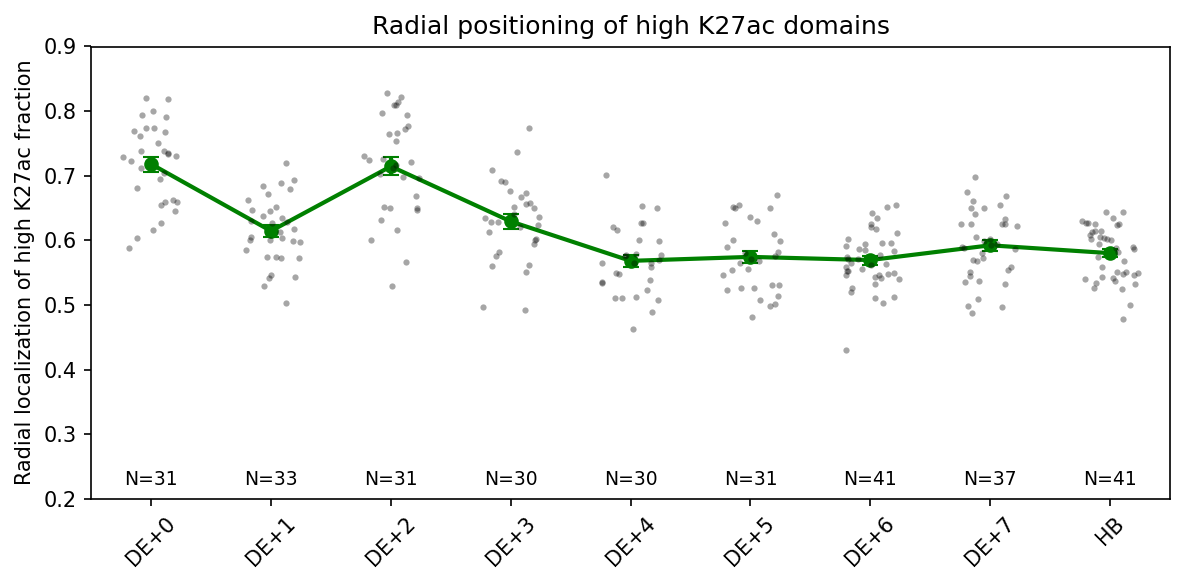

In [37]:
# plot the localization of K27ac high fraction
df_K27ac_plot = df.copy()

# enforce biological order
#timecourse_order = ["H1", "DE+0","DE+1","DE+2","DE+3","DE+4","DE+5","DE+6","DE+7", "HB", "iHep", "mHep"]
timecourse_order = ["DE+0","DE+1","DE+2","DE+3","DE+4","DE+5","DE+6","DE+7", "HB"]

# summarize mean, SD, N, SE
summary_df = (
    df_K27ac_plot
    .groupby("timecourse")["K27ac_high_frac_localization"]
    .agg(["mean", "std", "count"])
    .reindex(timecourse_order)
    .reset_index()
)

summary_df["se"] = summary_df["std"] / np.sqrt(summary_df["count"])

# x positions
x = np.arange(len(timecourse_order))

plt.figure(figsize=(8, 4), dpi=150)
ax = plt.gca()

# line plot with SE
ax.errorbar(
    x,
    summary_df["mean"],
    yerr=summary_df["se"],
    fmt="-o",
    linewidth=2,
    markersize=6,
    capsize=4,
    color="green",
    ecolor="green"
)

# optional: add individual points in light gray
sns.stripplot(
    data=df_K27ac_plot,
    x="timecourse",
    y="K27ac_high_frac_localization",
    order=timecourse_order,
    color="black",
    size=3,
    jitter=0.25,
    alpha=0.35,
    ax=ax
)

# reset x labels because errorbar uses numeric x
ax.set_xticks(x)
ax.set_xticklabels(timecourse_order, rotation=45)

ax.set_ylabel("Radial localization of high K27ac fraction")
ax.set_xlabel("")
ax.set_title("Radial positioning of high K27ac domains")

# y-axis from 0.2 to 1
ax.set_ylim(0.2, 0.9)

# Add N labels
for i, row in summary_df.iterrows():
    ax.text(
        i,
        0.215,
        f"N={int(row['count'])}",
        ha="center",
        va="bottom",
        fontsize=9
    )

plt.tight_layout()
plt.savefig(
    "/home/xiangru.huo-umw/scHiC/scripts/hardening_image/IF/Radial_positions_of_K27ac_domains_lineplot_SE_rep2.pdf",
    bbox_inches="tight")
plt.show()

/home/xiangru.huo-umw/conda/Jupiter/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/home/xiangru.huo-umw/conda/Jupiter/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/home/xiangru.huo-umw/conda/Jupiter/lib/python3.11/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)


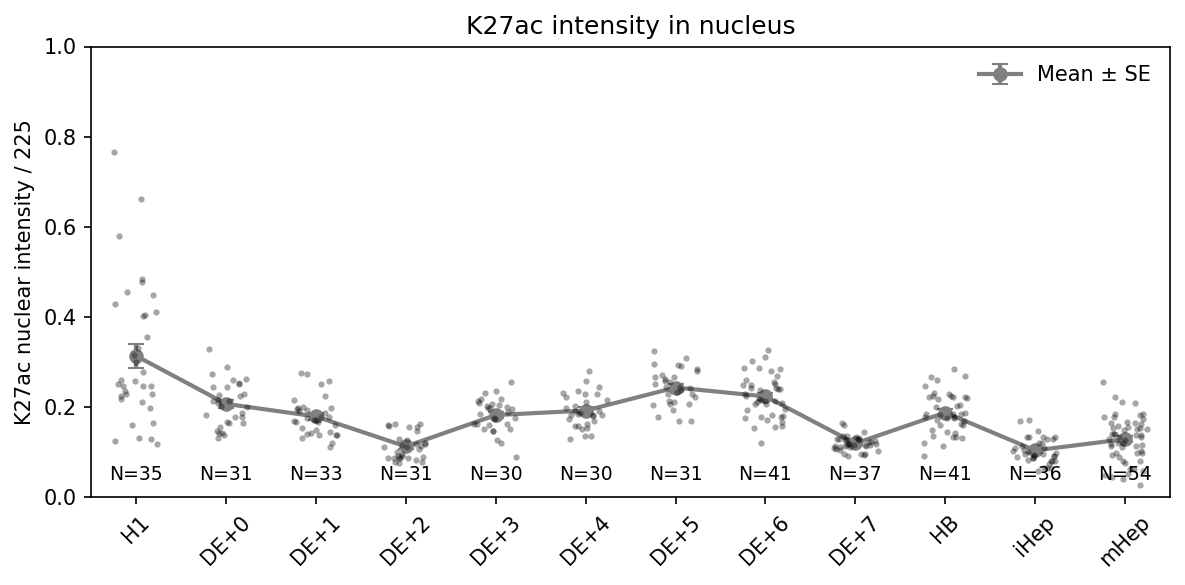

In [47]:
# plot the intensity of K27ac in nucleus
df_K27ac_plot = df.copy()

# -------------------------
# Prepare data
# -------------------------
timecourse_order = ["H1", "DE+0","DE+1","DE+2","DE+3","DE+4","DE+5","DE+6","DE+7", "HB", "iHep", "mHep"]
#timecourse_order = ["DE+0","DE+1","DE+2","DE+3","DE+4","DE+5","DE+6","DE+7", "HB"]

df_K27ac_plot["K27ac_mean_intensity_rel"] = (df_K27ac_plot["K27ac_nuclear_mean_intensity"] / 225.0)

df_K27ac_plot = df_K27ac_plot.dropna(
    subset=["timecourse", "K27ac_mean_intensity_rel"]
).copy()

df_K27ac_plot["timecourse"] = pd.Categorical(
    df_K27ac_plot["timecourse"],
    categories=timecourse_order,
    ordered=True
)

df_K27ac_plot = df_K27ac_plot[
    df_K27ac_plot["timecourse"].notna()
].copy()

# -------------------------
# Summarize mean, SD, N, SE
# -------------------------
summary_df = (
    df_K27ac_plot
    .groupby("timecourse", observed=False)
    .agg(
        mean=("K27ac_mean_intensity_rel", "mean"),
        std=("K27ac_mean_intensity_rel", "std"),
        count=("K27ac_mean_intensity_rel", "size")
    )
    .reindex(timecourse_order)
    .reset_index()
)

summary_df["se"] = summary_df["std"] / np.sqrt(summary_df["count"])

x = np.arange(len(timecourse_order))

# -------------------------
# Plot
# -------------------------
plt.figure(figsize=(8, 4), dpi=150)
ax = plt.gca()

# line plot with SE
ax.errorbar(
    x,
    summary_df["mean"],
    yerr=summary_df["se"],
    fmt="-o",
    linewidth=2,
    markersize=6,
    capsize=4,
    color="gray",
    ecolor="gray",
    label="Mean ± SE"
)

# individual points
sns.stripplot(
    data=df_K27ac_plot,
    x="timecourse",
    y="K27ac_mean_intensity_rel",
    order=timecourse_order,
    color="black",
    size=3,
    jitter=0.25,
    alpha=0.35,
    ax=ax
)

ax.set_xticks(x)
ax.set_xticklabels(timecourse_order, rotation=45)

ax.set_ylabel("K27ac nuclear intensity / 225")
ax.set_xlabel("")
ax.set_title("K27ac intensity in nucleus")

ax.set_ylim(0, 1)

# -------------------------
# Add N labels
# -------------------------
for i, row in summary_df.iterrows():
    n = 0 if pd.isna(row["count"]) else int(row["count"])
    ax.text(
        i,
        0.03,
        f"N={n}",
        ha="center",
        va="bottom",
        fontsize=9
    )

ax.legend(frameon=False)

plt.tight_layout()
plt.savefig(
    "/home/xiangru.huo-umw/scHiC/scripts/hardening_image/IF/K27ac_nuclear_intensity_12timepoints_lineplot_SE_rep2.pdf",
    bbox_inches="tight"
)
plt.show()

In [ ]:
#H3K9me3

In [ ]:
base_dir = "/home/xiangru.huo-umw/scHiC/scripts/hardening_image/IF/01-30-26/"
timecourses = [
    "ES", "DE", "HB", "iHep", "mHep"
]

In [ ]:
all_results = []

for tc in timecourses:
    print(f"\n=== Processing {tc} ===")

    folders = glob.glob(os.path.join(base_dir, f"{tc}_K9me3-488-*"))

    for folder in folders:
        print(f"  Folder: {folder}")

        green_images = sorted(glob.glob(os.path.join(folder, "*_ch01_SV.tif")))
        if len(green_images) == 0:
            print("    [SKIP] No green images found")
            continue

        for green_path in green_images:
            img_name = os.path.basename(green_path)
            print(f"    Processing: {img_name}")

            # infer blue channel path (nucleus)
            blue_path = green_path.replace("_ch01_", "_ch00_")
            if not os.path.exists(blue_path):
                print(f"    [SKIP] Blue channel not found: {blue_path}")
                continue

            # --------------------------------------------------
            # BLUE-defined nucleus + HIGH fraction (H3K9me3)
            # --------------------------------------------------
            metrics = plot_and_measure_high_fraction_using_blue_nucleus(
                green_path=green_path,
                blue_path=blue_path,
                blue_sigma=1.0,
                blue_closing_radius=10,
                blue_opening_radius=3,
                blue_min_nucleus_size=2000,
                blue_hole_area=2000,
                green_sigma=1.0,
                high_percentile=90,   # HIGH fraction only
            )

            if metrics is None:
                continue

            all_results.append({
                "timecourse": tc,
                "folder": os.path.basename(folder),
                "image": img_name,
                **metrics
            })

In [ ]:
#save results to csv
df = pd.DataFrame(all_results)

output_path = os.path.join(
    base_dir,
    "H3K9me3_localization_costainwithK9me2_results.csv"
)

df.to_csv(output_path, index=False)

print(f"Saved to: {output_path}")
print(f"Total cells: {len(df)}")

In [29]:
#reload the table
df = pd.read_csv(
    os.path.join(base_dir, "H3K9me3_localization_costainwithK9me2_results.csv")
)

df.head()

,timecourse,folder,image,blue_thr,high_thr,nucleus_area,nuclear_mean_intensity,nuclear_sum_intensity,high_pixel_count,high_sum_intensity,high_mean_intensity,high_frac_localization
0,ES,ES_K9me3-488_K9me2-594,013026-modification_cenpB_ES-H3K9me3-488-H3K9m...,24.933455,100.930226,260443,70.959652,1.848094e+07,25808,3.272779e+06,126.812563,0.739764
1,ES,ES_K9me3-488_K9me2-594,013026-modification_cenpB_ES-H3K9me3-488-H3K9m...,51.792545,97.330581,288548,64.886555,1.872289e+07,28492,3.889486e+06,136.511516,0.604643
2,ES,ES_K9me3-488_K9me2-594,013026-modification_cenpB_TileScan 2_P 22_ch01...,4.648610,127.383218,204710,87.919239,1.799795e+07,20154,3.576583e+06,177.462672,0.576542
3,ES,ES_K9me3-488_K9me2-594,013026-modification_cenpB_TileScan 2_P 23_ch01...,4.648610,114.467146,237068,75.638855,1.793155e+07,23432,4.277557e+06,182.551956,0.596924
4,ES,ES_K9me3-488_K9me2-594,013026-modification_cenpB_TileScan 3_P 1_ch01_...,18.171840,114.457355,136243,72.201073,9.836891e+06,13376,1.880203e+06,140.565384,0.787210


In [63]:
# =========================
# FULL SECTION (copy/paste)
#   - Blue-defined nucleus from *_ch00_*
#   - Signal from *_ch02_* (red) OR *_ch01_* (green)
#   - If signal image is RGB, project to 2D ("max" or "mean")
#   - Compute: nuclear mean/sum + HIGH-fraction mask metrics + radial localization
# =========================


# -------------------------
# 1) Blue nucleus segmentation (robust to unreadable tifs)
# -------------------------
def segment_nucleus_from_blue(
    blue_path,
    sigma=1.0,
    min_nucleus_size=2000,
    hole_area=2000,
    closing_radius=8,
    opening_radius=3,
    use_otsu=True,
    fallback_percentile=80,
):
    try:
        img = np.array(Image.open(blue_path))
    except (UnidentifiedImageError, OSError) as e:
        print(f"[SKIP] Cannot read blue image: {blue_path}  ({e})")
        return None, {"thr": None, "blue_smooth": None, "blue": None, "read_error": str(e)}

    # If it's RGB, take blue channel; if grayscale, use directly
    if img.ndim == 3 and img.shape[-1] >= 3:
        blue = img[:, :, 2].astype(np.float64)
    else:
        blue = img.astype(np.float64)

    smooth = filters.gaussian(blue, sigma=sigma)

    if use_otsu:
        thr = filters.threshold_otsu(smooth)
    else:
        thr = np.percentile(smooth, fallback_percentile)

    nuc = smooth > thr

    # Morphology to clean + smooth edge
    if opening_radius and opening_radius > 0:
        nuc = morphology.binary_opening(nuc, morphology.disk(opening_radius))
    if closing_radius and closing_radius > 0:
        nuc = morphology.binary_closing(nuc, morphology.disk(closing_radius))

    nuc = morphology.remove_small_objects(nuc, min_nucleus_size)
    nuc = morphology.remove_small_holes(nuc, hole_area)

    labels = measure.label(nuc)
    if labels.max() == 0:
        return None, {"thr": float(thr), "blue_smooth": smooth, "blue": blue, "read_error": None}

    largest = max(measure.regionprops(labels), key=lambda r: r.area)
    nuc = labels == largest.label

    return nuc, {"thr": float(thr), "blue_smooth": smooth, "blue": blue, "read_error": None}


# -------------------------
# 2) Read signal image as 2D (project if RGB)
# -------------------------
def read_signal_2d(signal_path, projection="max"):
    """
    Returns 2D float64.
    If RGB-like, project across channel axis to avoid channel-order confusion.
    """
    try:
        img = np.array(Image.open(signal_path))
    except (UnidentifiedImageError, OSError) as e:
        print(f"[SKIP] Cannot read signal image: {signal_path}  ({e})")
        return None

    if img.ndim == 3:
        if projection == "max":
            sig = img.max(axis=2)
        elif projection == "mean":
            sig = img.mean(axis=2)
        else:
            raise ValueError(f"Unknown projection='{projection}'")
    else:
        sig = img

    return sig.astype(np.float64)


# -------------------------
# 3) Mean intensity inside nucleus (ALL pixels)
# -------------------------
def mean_intensity_in_nucleus(
    signal_path,
    nucleus_mask,
    sigma_signal=1.0,
    projection="max",
):
    sig = read_signal_2d(signal_path, projection=projection)
    if sig is None:
        return None, None

    sig_s = filters.gaussian(sig, sigma=sigma_signal)
    vals = sig_s[nucleus_mask]
    if vals.size == 0:
        return None, None

    return float(vals.mean()), float(vals.sum())


# -------------------------
# 4) High-fraction metrics inside nucleus
# -------------------------
def high_fraction_metrics_in_nucleus(
    signal_path,
    nucleus_mask,
    # smoothing / denoise
    sigma_signal=1.0,
    sigma_high=1.5,        # extra smoothing ONLY for defining high mask
    high_percentile=80,

    # clean high mask
    min_high_size=80,
    high_hole_area=50,
    high_closing_radius=2,
    high_opening_radius=1,

    projection="max",
):
    sig = read_signal_2d(signal_path, projection=projection)
    if sig is None:
        return None

    # base smoothing (for intensity measurements)
    sig_s = filters.gaussian(sig, sigma=sigma_signal)

    # stronger smoothing (ONLY for defining high mask)
    sig_high = filters.gaussian(sig, sigma=sigma_high)

    vals = sig_high[nucleus_mask]
    if vals.size == 0:
        return None

    high_thr = np.percentile(vals, high_percentile)
    high_mask = nucleus_mask & (sig_high >= high_thr)

    # ---- clean high mask ----
    if high_opening_radius and high_opening_radius > 0:
        high_mask = morphology.binary_opening(high_mask, morphology.disk(high_opening_radius))
    if high_closing_radius and high_closing_radius > 0:
        high_mask = morphology.binary_closing(high_mask, morphology.disk(high_closing_radius))

    if min_high_size and min_high_size > 0:
        high_mask = morphology.remove_small_objects(high_mask, min_high_size)

    if high_hole_area and high_hole_area > 0:
        high_mask = morphology.remove_small_holes(high_mask, high_hole_area)

    # centroid + nuclear radius (for radial localization)
    ys, xs = np.where(nucleus_mask)
    cy, cx = ys.mean(), xs.mean()

    boundary = morphology.binary_dilation(nucleus_mask) ^ nucleus_mask
    by, bx = np.where(boundary)
    r_nuc = np.mean(np.sqrt((by - cy) ** 2 + (bx - cx) ** 2)) + 1e-9

    # measure intensity using sig_s (less aggressive smoothing)
    if high_mask.sum() == 0:
        high_loc = None
        high_sum = 0.0
        high_mean = None
        high_count = 0
    else:
        hy, hx = np.where(high_mask)
        high_int = sig_s[hy, hx]
        high_rad = np.sqrt((hy - cy) ** 2 + (hx - cx) ** 2) / r_nuc

        high_loc = float(np.sum(high_rad * high_int) / (np.sum(high_int) + 1e-9))
        high_sum = float(np.sum(high_int))
        high_mean = float(np.mean(high_int))
        high_count = int(len(high_int))

    return {
        "high_thr": float(high_thr),
        "high_mask": high_mask,
        "signal": sig,
        "signal_smooth": sig_s,
        "signal_high_smooth": sig_high,
        "high_frac_localization": high_loc,
        "high_sum_intensity": high_sum,
        "high_mean_intensity": high_mean,
        "high_pixel_count": high_count,
        "nucleus_area": int(nucleus_mask.sum()),
    }


# -------------------------
# 5) Plot + measure wrapper (NOW supports projection)
# -------------------------
def plot_and_measure_high_fraction_using_blue_nucleus(
    signal_path,
    blue_path,
    label="signal",
    # blue nucleus params
    blue_sigma=1.0,
    blue_closing_radius=10,
    blue_opening_radius=3,
    blue_min_nucleus_size=2000,
    blue_hole_area=2000,
    # signal params
    sigma_signal=1.0,
    sigma_high=1.5,
    high_percentile=90,
    min_high_size=80,
    high_hole_area=50,
    high_closing_radius=2,
    high_opening_radius=1,
    projection="max",
    overlay_alpha=0.45,
    show_plot=True,
):
    nuc_mask, nuc_dbg = segment_nucleus_from_blue(
        blue_path,
        sigma=blue_sigma,
        min_nucleus_size=blue_min_nucleus_size,
        hole_area=blue_hole_area,
        closing_radius=blue_closing_radius,
        opening_radius=blue_opening_radius,
        use_otsu=True,
    )
    if nuc_mask is None:
        print(f"[WARN] No nucleus found from blue: {blue_path}")
        return None

    out = high_fraction_metrics_in_nucleus(
        signal_path,
        nuc_mask,
        sigma_signal=sigma_signal,
        sigma_high=sigma_high,
        high_percentile=high_percentile,
        min_high_size=min_high_size,
        high_hole_area=high_hole_area,
        high_closing_radius=high_closing_radius,
        high_opening_radius=high_opening_radius,
        projection=projection,
    )
    if out is None:
        print(f"[WARN] No usable signal inside nucleus for: {signal_path}")
        return None

    # mean nuclear intensity (ALL pixels within blue-defined nucleus)
    nuc_mean, nuc_sum = mean_intensity_in_nucleus(
        signal_path,
        nuc_mask,
        sigma_signal=sigma_signal,
        projection=projection,
    )

    # outlines
    nuc_edge = morphology.binary_dilation(nuc_mask) ^ nuc_mask
    high_edge = morphology.binary_dilation(out["high_mask"]) ^ out["high_mask"]

    if show_plot:
        fig, axes = plt.subplots(1, 3, figsize=(18, 6))

        axes[0].imshow(out["signal"], cmap="gray")
        axes[0].set_title(f"{label} (raw/proj)")
        axes[0].axis("off")

        axes[1].imshow(nuc_dbg["blue"], cmap="gray")
        axes[1].imshow(nuc_edge.astype(float), alpha=0.9)
        axes[1].set_title(f"Blue nucleus (Otsu thr={nuc_dbg['thr']:.2f})")
        axes[1].axis("off")

        axes[2].imshow(out["signal"], cmap="gray")
        axes[2].imshow(out["high_mask"].astype(float), alpha=overlay_alpha)
        axes[2].imshow(nuc_edge.astype(float), alpha=0.9)
        axes[2].imshow(high_edge.astype(float), alpha=0.9)
        axes[2].set_title(f"{label} HIGH: ≥ P{high_percentile} (thr={out['high_thr']:.2f})")
        axes[2].axis("off")

        plt.tight_layout()
        plt.show()
        plt.close(fig)

    return {
        "blue_thr": float(nuc_dbg["thr"]) if nuc_dbg.get("thr") is not None else None,
        "high_thr": float(out["high_thr"]),
        "nucleus_area": int(out["nucleus_area"]),

        "nuclear_mean_intensity": nuc_mean,
        "nuclear_sum_intensity": nuc_sum,

        "high_pixel_count": int(out["high_pixel_count"]),
        "high_sum_intensity": float(out["high_sum_intensity"]),
        "high_mean_intensity": out["high_mean_intensity"],
        "high_frac_localization": out["high_frac_localization"],
    }


In [ ]:
# -------------------------
# 6) Batch loop: READ ch02 (RED) instead of ch01 (GREEN)
# -------------------------
all_results_red = []

for tc in timecourses:
    print(f"\n=== Processing {tc} (ch02/red) ===")

    folders = glob.glob(os.path.join(base_dir, f"{tc}*_K9me3-594"))
    # If your folders are named like "{tc}-H3K9me3-488-...", use this instead:
    # folders = glob.glob(os.path.join(base_dir, f"{tc}-H3K9me3-488-*"))

    for folder in folders:
        print(f"  Folder: {folder}")

        red_images = sorted(glob.glob(os.path.join(folder, "*_ch02_SV.tif")))
        if len(red_images) == 0:
            print("    [SKIP] No red images (*_ch02_SV.tif) found")
            continue

        for red_path in red_images:
            img_name = os.path.basename(red_path)
            print(f"    Processing: {img_name}")

            blue_path = red_path.replace("_ch02_", "_ch00_")
            if not os.path.exists(blue_path):
                print(f"    [SKIP] Blue channel not found: {blue_path}")
                continue

            metrics = plot_and_measure_high_fraction_using_blue_nucleus(
                signal_path=red_path,
                blue_path=blue_path,
                label="H3K9me2 (ch02)",
                blue_sigma=1.0,
                blue_closing_radius=10,
                blue_opening_radius=3,
                blue_min_nucleus_size=2000,
                blue_hole_area=2000,
                sigma_signal=1.0,
                sigma_high=1.5,
                high_percentile=90,
                min_high_size=80,
                projection="max",     # <-- now supported
                show_plot=False,      # set True to preview each image (can be slow)
            )

            if metrics is None:
                continue

            all_results_red.append({
                "timecourse": tc,
                "folder": os.path.basename(folder),
                "image": img_name,
                **metrics
            })

In [65]:
#save results to csv
df = pd.DataFrame(all_results_red)

output_path = os.path.join(
    base_dir,
    "H3K9me3_localization_costainwithCenpB_results.csv"
)

df.to_csv(output_path, index=False)

print(f"Saved to: {output_path}")
print(f"Total cells: {len(df)}")

Saved to: /home/xiangru.huo-umw/scHiC/scripts/hardening_image/IF/01-30-26/H3K9me3_localization_costainwithCenpB_results.csv
Total cells: 234


In [ ]:
#reload the table
df = pd.read_csv(
    os.path.join(base_dir, "H3K9me3_localization_costainwithCenpB_results.csv")
)

In [ ]:
#combine two batches of H3K9me3

In [ ]:
#reload the first table
df_me3 = pd.read_csv(
    os.path.join(base_dir, "H3K9me3_localization_costainwithK9me2_results.csv")
)

#conbined two batches of imaging together
df_me3_both = pd.concat([df, df_me3], ignore_index=True)

/home/xiangru.huo-umw/conda/Jupiter/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/home/xiangru.huo-umw/conda/Jupiter/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/home/xiangru.huo-umw/conda/Jupiter/lib/python3.11/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)


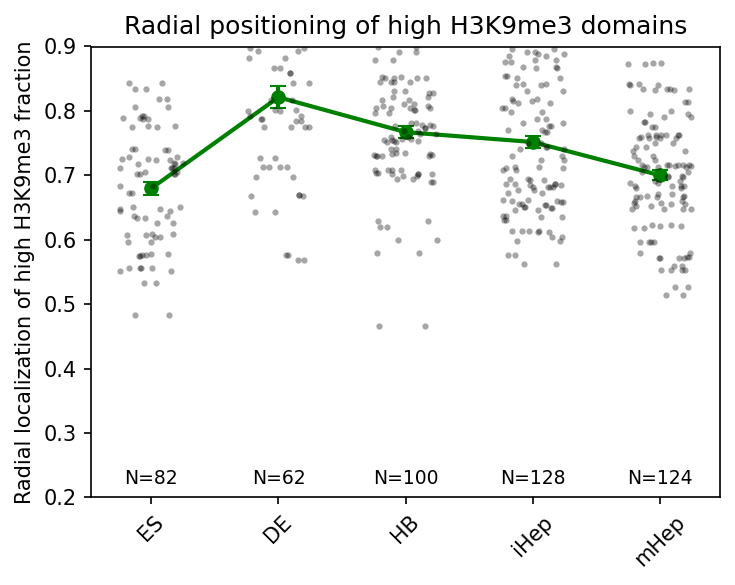

In [32]:
df_me3_plot = df_me3_both.copy()

# enforce biological order
timecourse_order = ["ES", "DE", "HB", "iHep", "mHep"]

# summarize mean, SD, N, and SE
summary_df = (
    df_me3_plot
    .groupby("timecourse")["high_frac_localization"]
    .agg(["mean", "std", "count"])
    .reindex(timecourse_order)
    .reset_index()
)

summary_df["se"] = summary_df["std"] / np.sqrt(summary_df["count"])

# x positions
x = np.arange(len(timecourse_order))

plt.figure(figsize=(5, 4), dpi=150)
ax = plt.gca()

# optional: show individual data points
sns.stripplot(
    data=df_me3_plot,
    x="timecourse",
    y="high_frac_localization",
    order=timecourse_order,
    color="black",
    size=3,
    jitter=0.25,
    alpha=0.35,
    ax=ax
)

# line plot with SE
ax.errorbar(
    x,
    summary_df["mean"],
    yerr=summary_df["se"],
    fmt="-o",
    linewidth=2,
    markersize=6,
    capsize=4,
    color="green",
    ecolor="green"
)

# x-axis
ax.set_xticks(x)
ax.set_xticklabels(timecourse_order, rotation=45)

# labels and title
ax.set_ylabel("Radial localization of high H3K9me3 fraction")
ax.set_xlabel("")
ax.set_title("Radial positioning of high H3K9me3 domains")

# y-axis
ax.set_ylim(0.2, 0.9)

# add N labels
for i, row in summary_df.iterrows():
    ax.text(
        i,
        0.215,
        f"N={int(row['count'])}",
        ha="center",
        va="bottom",
        fontsize=9
    )

plt.tight_layout()
plt.savefig(
    "/home/xiangru.huo-umw/scHiC/scripts/hardening_image/IF/Radial_positions_of_H3K9me3_domains_in_nucleus_across_5_stages_lineplot_SE.pdf",
    bbox_inches="tight"
)
plt.show()

# 8 days transition

In [76]:
base_dir = "/home/xiangru.huo-umw/scHiC/scripts/hardening_image/IF/10-11-25"

timecourses = [
    "H1", "DE", "DE+1", "DE+2", "DE+3", "DE+4", "DE+5", "DE+6", "DE+7",
    "HB", "HB+1", "HB+2", "iHep"
]

In [ ]:
all_results = []

for tc in timecourses:
    print(f"\n=== Processing {tc} ===")

    folders = glob.glob(os.path.join(base_dir, f"{tc}-H3K9me3-488-*"))

    for folder in folders:
        print(f"  Folder: {folder}")

        green_images = sorted(glob.glob(os.path.join(folder, "*_ch01_SV.tif")))
        if len(green_images) == 0:
            print("    [SKIP] No green images found")
            continue

        for green_path in green_images:
            img_name = os.path.basename(green_path)
            print(f"    Processing: {img_name}")

            # infer blue channel path (nucleus)
            blue_path = green_path.replace("_ch01_", "_ch00_")
            if not os.path.exists(blue_path):
                print(f"    [SKIP] Blue channel not found: {blue_path}")
                continue

            # --------------------------------------------------
            # BLUE-defined nucleus + HIGH fraction (H3K9me3)
            # --------------------------------------------------
            metrics = plot_and_measure_high_fraction_using_blue_nucleus(
                green_path=green_path,
                blue_path=blue_path,
                blue_sigma=1.0,
                blue_closing_radius=10,
                blue_opening_radius=3,
                blue_min_nucleus_size=2000,
                blue_hole_area=2000,
                green_sigma=1.0,
                high_percentile=80,   # HIGH fraction only
            )

            if metrics is None:
                continue

            all_results.append({
                "timecourse": tc,
                "folder": os.path.basename(folder),
                "image": img_name,
                **metrics
            })

In [44]:
#save results to csv
df = pd.DataFrame(all_results)

output_path = os.path.join(
    base_dir,
    "H3K9me3_localization_batch_results.csv"
)

df.to_csv(output_path, index=False)

print(f"Saved to: {output_path}")
print(f"Total cells: {len(df)}")

Saved to: /home/xiangru.huo-umw/scHiC/scripts/hardening_image/IF/10-11-25/H3K9me3_localization_batch_results.csv
Total cells: 220


In [ ]:
#reload the table
df = pd.read_csv(
    os.path.join(base_dir, "H3K9me3_localization_batch_results.csv")
)


# More cell captured for H3K9me3 over 8 days.

In [79]:
base_dir_2 = "/home/xiangru.huo-umw/scHiC/scripts/hardening_image/IF/12-20-2025"

timecourses = [
    "DE+1", "DE+2", "DE+3", "DE+4", "DE+5", "DE+6", "DE+7","HB"
]

In [ ]:
all_results = []

for tc in timecourses:
    print(f"\n=== Processing {tc} ===")

    folders = glob.glob(os.path.join(base_dir_2, f"{tc}-H3K9me3-488-*"))

    for folder in folders:
        print(f"  Folder: {folder}")

        green_images = sorted(glob.glob(os.path.join(folder, "*_ch01_SV.tif")))
        if len(green_images) == 0:
            print("    [SKIP] No green images found")
            continue

        for green_path in green_images:
            img_name = os.path.basename(green_path)
            print(f"    Processing: {img_name}")

            # infer blue channel path (nucleus)
            blue_path = green_path.replace("_ch01_", "_ch00_")
            if not os.path.exists(blue_path):
                print(f"    [SKIP] Blue channel not found: {blue_path}")
                continue

            # --------------------------------------------------
            # BLUE-defined nucleus + HIGH fraction (H3K9me3)
            # --------------------------------------------------
            metrics = plot_and_measure_high_fraction_using_blue_nucleus(
                green_path=green_path,
                blue_path=blue_path,
                blue_sigma=1.0,
                blue_closing_radius=10,
                blue_opening_radius=3,
                blue_min_nucleus_size=2000,
                blue_hole_area=2000,
                green_sigma=1.0,
                high_percentile=80,   # HIGH fraction only
            )

            if metrics is None:
                continue

            all_results.append({
                "timecourse": tc,
                "folder": os.path.basename(folder),
                "image": img_name,
                **metrics
            })

In [ ]:
#save results to csv
df_me3 = pd.DataFrame(all_results)

output_path = os.path.join(
    base_dir_2,
    "H3K9me3_localization_batch_results.csv"
)

df_me3.to_csv(output_path, index=False)

print(f"Saved to: {output_path}")
print(f"Total cells: {len(df)}")

In [80]:
#reload the table
df_me3= pd.read_csv(
    os.path.join(base_dir_2, "H3K9me3_localization_batch_results.csv")
)

In [81]:
#conbined two batches of imaging together
df_me3_both = pd.concat([df, df_me3], ignore_index=True)
df_me3_both.head()

,timecourse,folder,image,blue_thr,high_thr,nucleus_area,nuclear_mean_intensity,nuclear_sum_intensity,high_pixel_count,high_sum_intensity,high_mean_intensity,high_frac_localization
0,H1,H1-H3K9me3-488-H3K9me2-594,10072025-modification_ES-H3K9me3-488-H3K9m2-59...,48.476229,18.423660,415387,13.232322,5.496534e+06,82252,2.822253e+06,34.312277,0.833700
1,H1,H1-H3K9me3-488-H3K9me2-594,10072025-modification_Untreated_007_ch01_SV.tif,52.997207,24.750124,140123,17.681592,2.477598e+06,27307,1.050765e+06,38.479707,0.839849
2,H1,H1-H3K9me3-488-H3K9me2-594,10072025-modification_Untreated_008_ch01_SV.tif,50.475101,35.577354,222188,26.700634,5.932561e+06,43201,2.700765e+06,62.516273,0.622151
3,H1,H1-H3K9me3-488-H3K9me2-594,10072025-modification_Untreated_009_ch01_SV.tif,57.807143,26.947821,194673,21.472822,4.180179e+06,37087,2.036353e+06,54.907474,0.626289
4,H1,H1-H3K9me3-488-H3K9me2-594,10072025-modification_Untreated_010_ch01_SV.tif,60.790847,25.477576,189524,22.125328,4.193281e+06,37106,2.275558e+06,61.325866,0.511178


In [82]:
#load the K9me3 from 5stages
base_dir = "/home/xiangru.huo-umw/scHiC/scripts/hardening_image/IF/01-30-26/"
timecourses = [
    "ES", "DE", "HB", "iHep", "mHep"]

#reload the table1
df_5stages1 = pd.read_csv(
    os.path.join(base_dir, "H3K9me3_localization_costainwithK9me2_results.csv")
)

#conbined two batches of imaging together
df_me3_both2 = pd.concat([df_5stages1, df_me3_both], ignore_index=True)

/home/xiangru.huo-umw/conda/Jupiter/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/home/xiangru.huo-umw/conda/Jupiter/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/home/xiangru.huo-umw/conda/Jupiter/lib/python3.11/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)


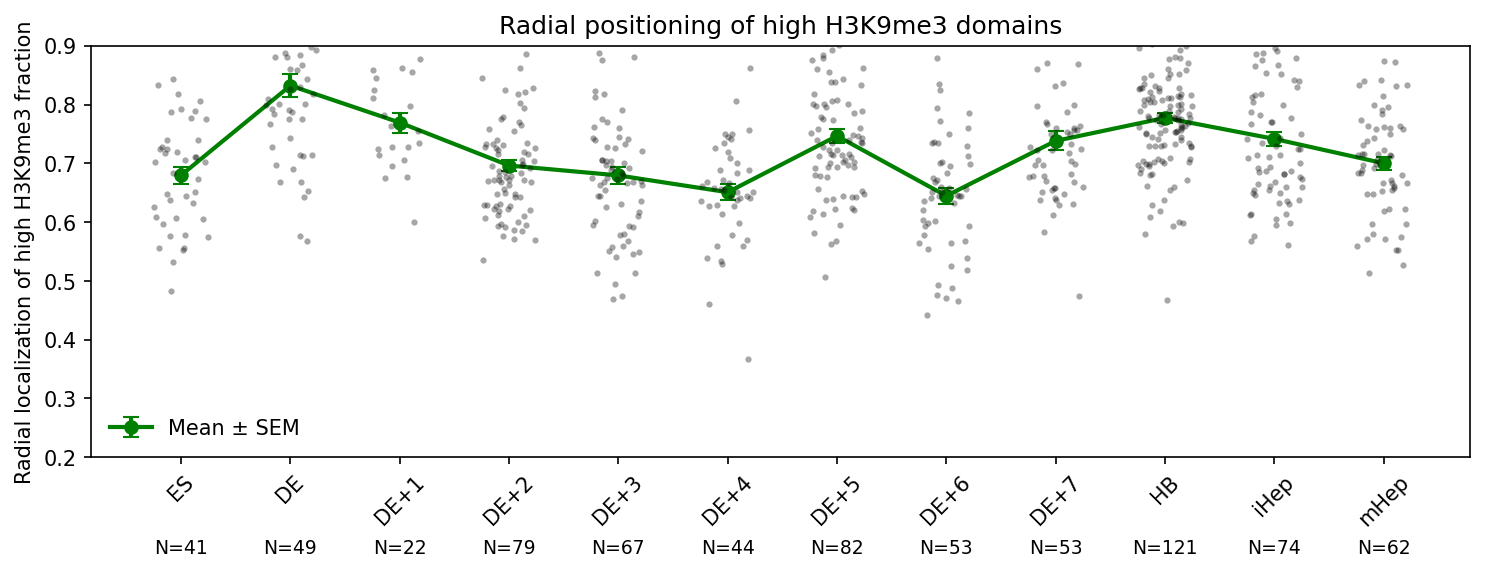

In [124]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# -------------------------
# Prepare data
# -------------------------
#timecourse_order = ["DE", "DE+1", "DE+2", "DE+3", "DE+4", "DE+5", "DE+6", "DE+7", "HB"]
timecourse_order = ["ES", "DE", "DE+1", "DE+2", "DE+3", "DE+4", "DE+5", "DE+6", "DE+7", "HB","iHep","mHep"]

exclude_timecourses = ["HB+1", "HB+2"]

df_me3_plot = df_me3_both2[
    ~df_me3_both2["timecourse"].isin(exclude_timecourses)
].copy()

df_me3_plot["timecourse"] = pd.Categorical(
    df_me3_plot["timecourse"],
    categories=timecourse_order,
    ordered=True
)

df_me3_plot = df_me3_plot.dropna(subset=["high_frac_localization"])

# -------------------------
# Summary table
# -------------------------
summary_df = (
    df_me3_plot
    .groupby("timecourse", observed=False)
    .agg(
        mean_loc=("high_frac_localization", "mean"),
        median_loc=("high_frac_localization", "median"),
        sem_loc=("high_frac_localization", lambda x: x.std(ddof=1) / np.sqrt(len(x))),
        n=("high_frac_localization", "size")
    )
    .reindex(timecourse_order)
    .reset_index()
)

summary_df["x"] = np.arange(len(summary_df))

# -------------------------
# Plot line plot
# -------------------------
plt.figure(figsize=(10, 4), dpi=150)
ax = plt.gca()

# individual points
sns.stripplot(
    data=df_me3_plot,
    x="timecourse",
    y="high_frac_localization",
    order=timecourse_order,
    color="black",
    size=3,
    jitter=0.25,
    alpha=0.35,
    ax=ax
)

# mean line
ax.errorbar(
    summary_df["x"],
    summary_df["mean_loc"],
    yerr=summary_df["sem_loc"],
    marker="o",
    linewidth=2,
    capsize=4,
    color="green",
    label="Mean ± SEM"
)


# -------------------------
# Add N labels
# -------------------------
for i, row in summary_df.iterrows():
    ax.text(
        i,
        0.03,
        f"N={int(row['n']) if not pd.isna(row['n']) else 0}",
        ha="center",
        va="bottom",
        fontsize=9
    )

ax.set_xticks(summary_df["x"])
ax.set_xticklabels(timecourse_order, rotation=45)

ax.set_ylabel("Radial localization of high H3K9me3 fraction")
ax.set_xlabel("")
ax.set_title("Radial positioning of high H3K9me3 domains")
ax.set_ylim(0.2, 0.9)

ax.legend(frameon=False)

plt.tight_layout()
plt.savefig(
    "/home/xiangru.huo-umw/scHiC/scripts/hardening_image/IF/Radial_positions_of_H3K9me3_domains_12timpoints_in_nucleus_lineplot.pdf"
)
plt.show()

/home/xiangru.huo-umw/conda/Jupiter/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/home/xiangru.huo-umw/conda/Jupiter/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/home/xiangru.huo-umw/conda/Jupiter/lib/python3.11/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)


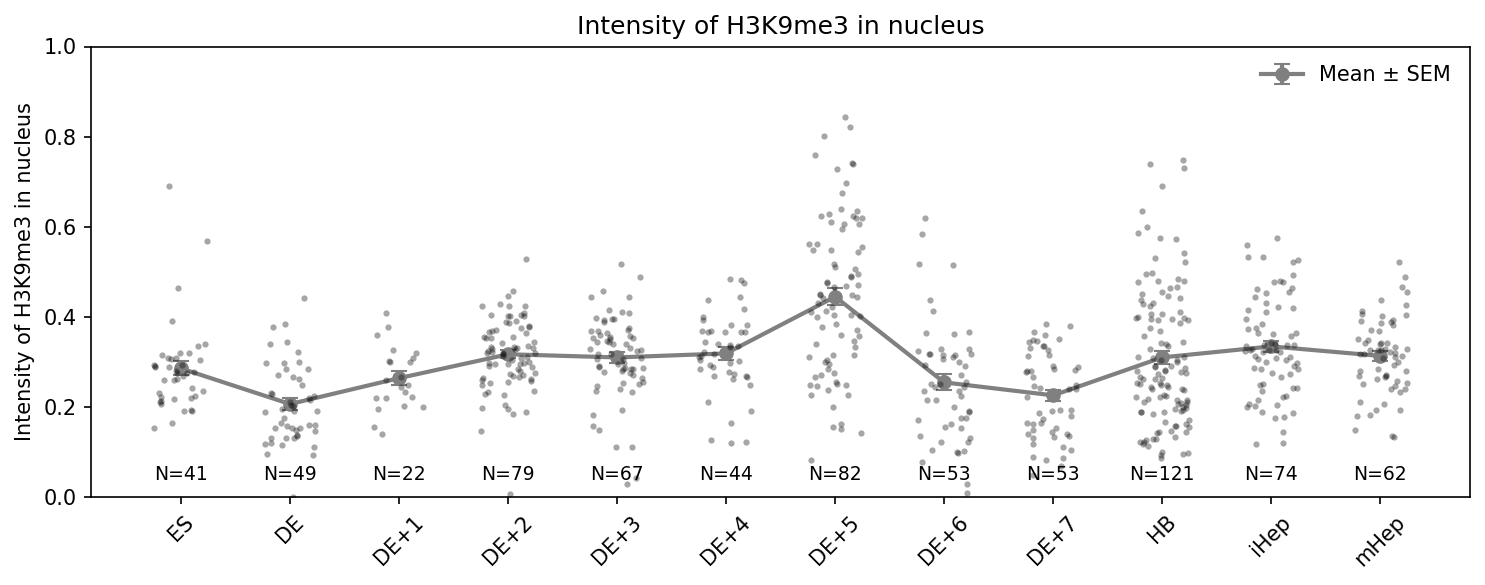

In [125]:
# -------------------------
# Prepare data
# -------------------------
df_me3_both2["h3k9me3_mean_intensity_rel"] = (
    df_me3_both2["nuclear_mean_intensity"] / 225.0
)

#timecourse_order = ["DE", "DE+1", "DE+2", "DE+3", "DE+4","DE+5", "DE+6", "DE+7", "HB"]
timecourse_order = ["ES", "DE", "DE+1", "DE+2", "DE+3", "DE+4", "DE+5", "DE+6", "DE+7", "HB","iHep","mHep"]

exclude_timecourses = ["H1", "HB+1", "HB+2"]

df_me3_plot = df_me3_both2[
    ~df_me3_both2["timecourse"].isin(exclude_timecourses)
].copy()

df_me3_plot["timecourse"] = pd.Categorical(
    df_me3_plot["timecourse"],
    categories=timecourse_order,
    ordered=True
)

df_me3_plot = df_me3_plot.dropna(
    subset=["h3k9me3_mean_intensity_rel"]
)

# -------------------------
# Summary table
# -------------------------
summary_df = (
    df_me3_plot
    .groupby("timecourse", observed=False)
    .agg(
        mean_intensity=("h3k9me3_mean_intensity_rel", "mean"),
        median_intensity=("h3k9me3_mean_intensity_rel", "median"),
        sem_intensity=(
            "h3k9me3_mean_intensity_rel",
            lambda x: x.std(ddof=1) / np.sqrt(len(x))
        ),
        n=("h3k9me3_mean_intensity_rel", "size")
    )
    .reindex(timecourse_order)
    .reset_index()
)

summary_df["x"] = np.arange(len(summary_df))

# -------------------------
# Plot
# -------------------------
plt.figure(figsize=(10, 4), dpi=150)
ax = plt.gca()

# individual points
sns.stripplot(
    data=df_me3_plot,
    x="timecourse",
    y="h3k9me3_mean_intensity_rel",
    order=timecourse_order,
    color="black",
    size=3,
    jitter=0.25,
    alpha=0.35,
    ax=ax
)

# mean ± SEM line
ax.errorbar(
    summary_df["x"],
    summary_df["mean_intensity"],
    yerr=summary_df["sem_intensity"],
    marker="o",
    linewidth=2,
    capsize=4,
    color="gray",
    label="Mean ± SEM"
)

# -------------------------
# Add N labels
# -------------------------
for i, row in summary_df.iterrows():
    n = 0 if pd.isna(row["n"]) else int(row["n"])
    ax.text(
        i,
        0.03,
        f"N={n}",
        ha="center",
        va="bottom",
        fontsize=9
    )

ax.set_xticks(summary_df["x"])
ax.set_xticklabels(timecourse_order, rotation=45)

ax.set_ylabel("Intensity of H3K9me3 in nucleus")
ax.set_xlabel("")
ax.set_title("Intensity of H3K9me3 in nucleus")
ax.set_ylim(0, 1)

ax.legend(frameon=False)

plt.tight_layout()
plt.savefig(
    "/home/xiangru.huo-umw/scHiC/scripts/hardening_image/IF/Intensity_of_H3K9me3_12timepoints_in_nucleus_lineplot.pdf"
)
plt.show()

# H3K9me2 localization and intensity

In [90]:
def load_signal_image(signal_path, projection="max"):
    try:
        img = np.array(Image.open(signal_path))
    except (UnidentifiedImageError, OSError) as e:
        print(f"[SKIP] Cannot read signal image: {signal_path}  ({e})")
        return None

    if img.ndim == 3:
        if projection == "max":
            sig = img.max(axis=2)
        elif projection == "mean":
            sig = img.mean(axis=2)
        else:
            raise ValueError(f"Unknown projection: {projection}")
    else:
        sig = img

    return sig.astype(np.float64)


def mean_intensity_in_nucleus(
    signal_path,
    nucleus_mask,
    sigma_signal=1.0,
    projection="max"
):
    sig = load_signal_image(signal_path, projection=projection)
    sig_s = filters.gaussian(sig, sigma=sigma_signal)

    vals = sig_s[nucleus_mask]
    if vals.size == 0:
        return None, None

    return float(vals.mean()), float(vals.sum())


def high_fraction_metrics_in_nucleus(
    signal_path,
    nucleus_mask,
    sigma_signal=1.0,
    sigma_high=1.5,
    high_percentile=80,
    min_high_size=80,
    high_hole_area=50,
    high_closing_radius=2,
    high_opening_radius=1,
    projection="max",
):
    sig = load_signal_image(signal_path, projection=projection)

    sig_s = filters.gaussian(sig, sigma=sigma_signal)
    sig_high = filters.gaussian(sig, sigma=sigma_high)

    vals = sig_high[nucleus_mask]
    if vals.size == 0:
        return None

    high_thr = np.percentile(vals, high_percentile)
    high_mask = nucleus_mask & (sig_high >= high_thr)

    # clean high mask
    if high_opening_radius and high_opening_radius > 0:
        high_mask = morphology.binary_opening(high_mask, morphology.disk(high_opening_radius))
    if high_closing_radius and high_closing_radius > 0:
        high_mask = morphology.binary_closing(high_mask, morphology.disk(high_closing_radius))
    if min_high_size and min_high_size > 0:
        high_mask = morphology.remove_small_objects(high_mask, min_high_size)
    if high_hole_area and high_hole_area > 0:
        high_mask = morphology.remove_small_holes(high_mask, high_hole_area)

    # radial localization
    ys, xs = np.where(nucleus_mask)
    cy, cx = ys.mean(), xs.mean()
    boundary = morphology.binary_dilation(nucleus_mask) ^ nucleus_mask
    by, bx = np.where(boundary)
    r_nuc = np.mean(np.sqrt((by - cy)**2 + (bx - cx)**2)) + 1e-9

    if high_mask.sum() == 0:
        high_loc = None
        high_sum = 0.0
        high_mean = None
        high_count = 0
    else:
        hy, hx = np.where(high_mask)
        high_int = sig_s[hy, hx]
        high_rad = np.sqrt((hy - cy)**2 + (hx - cx)**2) / r_nuc

        high_loc = float(np.sum(high_rad * high_int) / (np.sum(high_int) + 1e-9))
        high_sum = float(np.sum(high_int))
        high_mean = float(np.mean(high_int))
        high_count = int(len(high_int))

    return {
        "high_thr": float(high_thr),
        "high_mask": high_mask,
        "signal": sig,
        "signal_smooth": sig_s,
        "signal_high_smooth": sig_high,
        "high_frac_localization": high_loc,
        "high_sum_intensity": high_sum,
        "high_mean_intensity": high_mean,
        "high_pixel_count": high_count,
        "nucleus_area": int(nucleus_mask.sum()),
    }

def plot_and_measure_high_fraction_using_blue_nucleus(
    signal_path,
    blue_path,
    label="H3K9me2",
    blue_sigma=1.0,
    blue_closing_radius=8,
    blue_opening_radius=3,
    blue_min_nucleus_size=2000,
    blue_hole_area=2000,
    sigma_signal=1.0,
    sigma_high=1.5,
    high_percentile=80,   #change the threshold at here
    min_high_size=80,
    overlay_alpha=0.45,
    channel_idx=None,
):
    nuc_mask, nuc_dbg = segment_nucleus_from_blue(
        blue_path,
        sigma=blue_sigma,
        min_nucleus_size=blue_min_nucleus_size,
        hole_area=blue_hole_area,
        closing_radius=blue_closing_radius,
        opening_radius=blue_opening_radius,
        use_otsu=True,
    )
    if nuc_mask is None:
        print(f"[WARN] No nucleus found from blue: {blue_path}")
        return None

    out = high_fraction_metrics_in_nucleus(
        signal_path,
        nuc_mask,
        sigma_signal=sigma_signal,
        sigma_high=sigma_high,
        high_percentile=high_percentile,
        min_high_size=min_high_size,
        projection="max"
    )
    if out is None:
        print(f"[WARN] No signal values inside nucleus for: {signal_path}")
        return None

    nuc_mean, nuc_sum = mean_intensity_in_nucleus(
        signal_path,
        nuc_mask,
        sigma_signal=sigma_signal,projection="max")

    nuc_edge = morphology.binary_dilation(nuc_mask) ^ nuc_mask
    high_edge = morphology.binary_dilation(out["high_mask"]) ^ out["high_mask"]

    # plot
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))

    axes[0].imshow(out["signal"], cmap="gray")
    axes[0].set_title(f"{label} signal (raw)")
    axes[0].axis("off")

    axes[1].imshow(nuc_dbg["blue"], cmap="gray")
    axes[1].imshow(nuc_edge.astype(float), alpha=0.9)
    axes[1].set_title(f"Blue nucleus mask (Otsu thr={nuc_dbg['thr']:.2f})")
    axes[1].axis("off")

    axes[2].imshow(out["signal"], cmap="gray")
    axes[2].imshow(out["high_mask"].astype(float), alpha=overlay_alpha)
    axes[2].imshow(nuc_edge.astype(float), alpha=0.9)
    axes[2].imshow(high_edge.astype(float), alpha=0.9)
    axes[2].set_title(f"{label} high fraction: ≥ P{high_percentile} (thr={out['high_thr']:.2f})")
    axes[2].axis("off")

    plt.tight_layout()
    plt.show()
    plt.close(fig)

    return {
        "blue_thr": float(nuc_dbg["thr"]),
        "high_thr": float(out["high_thr"]),
        "nucleus_area": int(out["nucleus_area"]),
        "nuclear_mean_intensity": nuc_mean,
        "nuclear_sum_intensity": nuc_sum,
        "high_pixel_count": int(out["high_pixel_count"]),
        "high_sum_intensity": float(out["high_sum_intensity"]),
        "high_mean_intensity": out["high_mean_intensity"],
        "high_frac_localization": out["high_frac_localization"],
    }

In [91]:
base_dir = "/home/xiangru.huo-umw/scHiC/scripts/hardening_image/IF/01-30-26/"

timecourses = [
    "ES", "DE", "HB", "iHep", "mHep"
]

In [ ]:
all_results_2me = []

for tc in timecourses:
    print(f"\n=== Processing {tc} (H3K9me2) ===")

    folders = glob.glob(
        os.path.join(base_dir, f"{tc}*_K9me2-594")
    )

    for folder in folders:
        print(f"  Folder: {folder}")

        # red channel = H3K9me2
        red_images = sorted(glob.glob(os.path.join(folder, "*_ch02_SV.tif")))
        if len(red_images) == 0:
            print("    [SKIP] No red images found")
            continue

        for red_path in red_images:
            img_name = os.path.basename(red_path)
            print(f"    Processing: {img_name}")

            # infer blue channel (nucleus)
            blue_path = None
            if "_ch02_" in red_path:
                blue_path = red_path.replace("_ch02_", "_ch00_")
            elif "_chr02_" in red_path:   # just in case
                blue_path = red_path.replace("_chr02_", "_ch00_")

            if blue_path is None or not os.path.exists(blue_path):
                print(f"    [SKIP] Blue channel not found for: {img_name}")
                continue

            # --------------------------------------------------
            # BLUE-defined nucleus + HIGH fraction (H3K9me2)
            # --------------------------------------------------
            metrics = plot_and_measure_high_fraction_using_blue_nucleus(
                signal_path=red_path,
                blue_path=blue_path,
                label="H3K9me2",
                blue_sigma=1.0,
                blue_closing_radius=8,
                blue_opening_radius=3,
                blue_min_nucleus_size=2000,
                blue_hole_area=2000,
                sigma_signal=1.0,
                sigma_high=1.5,
                high_percentile=80,   # same definition as H3K9me3
                min_high_size=80,
            )

            if metrics is None:
                continue

            all_results_2me.append({
                "timecourse": tc,
                "folder": os.path.basename(folder),
                "image": img_name,
                **metrics
            })

In [ ]:
#save the data
df_me2 = pd.DataFrame(all_results_2me)

output_path = os.path.join(base_dir, "H3K9me2_localization_costainedH3K9me3_results.csv")
df_me2.to_csv(output_path, index=False)

In [ ]:
base_dir = "/home/xiangru.huo-umw/scHiC/scripts/hardening_image/IF/01-30-26/"

timecourses = [
    "ES", "DE", "HB", "iHep", "mHep"
]

df_me2 = pd.read_csv(
    os.path.join(base_dir, "H3K9me2_localization_costainedH3K9me3_results.csv")
)


In [ ]:
#8 days transition

In [101]:
base_dir = "/home/xiangru.huo-umw/scHiC/scripts/hardening_image/IF/10-11-25"

timecourses = [
    "H1", "DE", "DE+1", "DE+2", "DE+3", "DE+4", "DE+5", "DE+6", "DE+7",
    "HB", "HB+1", "HB+2", "iHep"
]

In [ ]:
all_results_2me = []

for tc in timecourses:
    print(f"\n=== Processing {tc} (H3K9me2) ===")

    folders = glob.glob(
        os.path.join(base_dir, f"{tc}-H3K9me3-488-H3K9me2-594")
    )

    for folder in folders:
        print(f"  Folder: {folder}")

        # red channel = H3K9me2
        red_images = sorted(glob.glob(os.path.join(folder, "*_ch02_SV.tif")))
        if len(red_images) == 0:
            print("    [SKIP] No red images found")
            continue

        for red_path in red_images:
            img_name = os.path.basename(red_path)
            print(f"    Processing: {img_name}")

            # infer blue channel (nucleus)
            blue_path = None
            if "_ch02_" in red_path:
                blue_path = red_path.replace("_ch02_", "_ch00_")
            elif "_chr02_" in red_path:   # just in case
                blue_path = red_path.replace("_chr02_", "_ch00_")

            if blue_path is None or not os.path.exists(blue_path):
                print(f"    [SKIP] Blue channel not found for: {img_name}")
                continue

            # --------------------------------------------------
            # BLUE-defined nucleus + HIGH fraction (H3K9me2)
            # --------------------------------------------------
            metrics = plot_and_measure_high_fraction_using_blue_nucleus(
                signal_path=red_path,
                blue_path=blue_path,
                label="H3K9me2",
                blue_sigma=1.0,
                blue_closing_radius=8,
                blue_opening_radius=3,
                blue_min_nucleus_size=2000,
                blue_hole_area=2000,
                sigma_signal=1.0,
                sigma_high=1.5,
                high_percentile=80,   # same definition as H3K9me3
                min_high_size=80,
            )

            if metrics is None:
                continue

            all_results_2me.append({
                "timecourse": tc,
                "folder": os.path.basename(folder),
                "image": img_name,
                **metrics
            })

In [56]:
#save the data
df_me2 = pd.DataFrame(all_results_2me)

output_path = os.path.join(base_dir, "H3K9me2_localization_batch_results.csv")
df_me2.to_csv(output_path, index=False)

In [102]:
df_me2 = pd.read_csv(
    os.path.join(base_dir, "H3K9me2_localization_batch_results.csv")
)

df_me2.head()

,timecourse,folder,image,blue_thr,high_thr,nucleus_area,nuclear_mean_intensity,nuclear_sum_intensity,high_pixel_count,high_sum_intensity,high_mean_intensity,high_frac_localization
0,H1,H1-H3K9me3-488-H3K9me2-594,10072025-modification_ES-H3K9me3-488-H3K9m2-59...,48.476229,16.949137,413706,12.504731,5.173282e+06,80811,1.914407e+06,23.689928,0.840137
1,H1,H1-H3K9me3-488-H3K9me2-594,10072025-modification_Untreated_007_ch02_SV.tif,52.997207,13.251875,137459,10.181267,1.399507e+06,26299,4.926183e+05,18.731447,1.049414
2,H1,H1-H3K9me3-488-H3K9me2-594,10072025-modification_Untreated_008_ch02_SV.tif,50.475101,17.121123,219785,13.086141,2.876137e+06,42368,1.105214e+06,26.086060,0.865498
3,H1,H1-H3K9me3-488-H3K9me2-594,10072025-modification_Untreated_009_ch02_SV.tif,57.807143,16.037277,192288,12.473379,2.398481e+06,36936,8.118614e+05,21.980219,0.988667
4,H1,H1-H3K9me3-488-H3K9me2-594,10072025-modification_Untreated_010_ch02_SV.tif,60.790847,17.568354,189523,13.569802,2.571790e+06,36182,9.344420e+05,25.826156,0.804091


# More cell captured for H3K9me2.

In [105]:
base_dir_2 = "/home/xiangru.huo-umw/scHiC/scripts/hardening_image/IF/12-20-2025"

timecourses = [
    "DE+1", "DE+2", "DE+3", "DE+4", "DE+5", "DE+6", "DE+7","HB"
]

In [ ]:
all_results_2me2 = []

for tc in timecourses:
    print(f"\n=== Processing {tc} (H3K9me2) ===")

    folders = glob.glob(
        os.path.join(base_dir_2, f"{tc}-H3K9me3-488-H3K9me2-594")
    )

    for folder in folders:
        print(f"  Folder: {folder}")

        # red channel = H3K9me2
        red_images = sorted(glob.glob(os.path.join(folder, "*_ch02_SV.tif")))
        if len(red_images) == 0:
            print("    [SKIP] No red images found")
            continue

        for red_path in red_images:
            img_name = os.path.basename(red_path)
            print(f"    Processing: {img_name}")

            # infer blue channel (nucleus)
            blue_path = None
            if "_ch02_" in red_path:
                blue_path = red_path.replace("_ch02_", "_ch00_")
            elif "_chr02_" in red_path:   # just in case
                blue_path = red_path.replace("_chr02_", "_ch00_")

            if blue_path is None or not os.path.exists(blue_path):
                print(f"    [SKIP] Blue channel not found for: {img_name}")
                continue

            # --------------------------------------------------
            # BLUE-defined nucleus + HIGH fraction (H3K9me2)
            # --------------------------------------------------
            metrics = plot_and_measure_high_fraction_using_blue_nucleus(
                signal_path=red_path,
                blue_path=blue_path,
                label="H3K9me2",
                blue_sigma=1.0,
                blue_closing_radius=8,
                blue_opening_radius=3,
                blue_min_nucleus_size=2000,
                blue_hole_area=2000,
                sigma_signal=1.0,
                sigma_high=1.5,
                high_percentile=80,   # same definition as H3K9me3
                min_high_size=80,
            )

            if metrics is None:
                continue

            all_results_2me2.append({
                "timecourse": tc,
                "folder": os.path.basename(folder),
                "image": img_name,
                **metrics
            })

In [128]:
#save the data
df_me2_2 = pd.DataFrame(all_results_2me2)

output_path = os.path.join(base_dir_2, "H3K9me2_localization_batch_results.csv")
df_me2_2.to_csv(output_path, index=False)

In [106]:
#load data in batch2
df_me2_2 = pd.read_csv(
    os.path.join(base_dir_2, "H3K9me2_localization_batch_results.csv")
)

df_me2_2.head()

,timecourse,folder,image,blue_thr,high_thr,nucleus_area,nuclear_mean_intensity,nuclear_sum_intensity,high_pixel_count,high_sum_intensity,high_mean_intensity,high_frac_localization
0,H1,H1-H3K9me3-488-H3K9me2-594,12192025-modification_H1-H3K9me3-488-H3K9me2_5...,26.623858,29.160169,165952,22.880559,3.797074e+06,32657,1.161732e+06,35.573741,0.666818
1,H1,H1-H3K9me3-488-H3K9me2-594,12192025-modification_TileScan 5_P 10_ch02_SV.tif,31.695070,29.046975,83416,22.752881,1.897954e+06,16667,5.936806e+05,35.620121,0.636751
2,H1,H1-H3K9me3-488-H3K9me2-594,12192025-modification_TileScan 5_P 11_ch02_SV.tif,30.004666,28.785777,124779,21.996325,2.744679e+06,24827,8.520822e+05,34.320788,0.837215
3,H1,H1-H3K9me3-488-H3K9me2-594,12192025-modification_TileScan 5_P 12_ch02_SV.tif,30.849868,48.580909,111908,37.354195,4.180233e+06,21866,1.344959e+06,61.509150,0.684591
4,H1,H1-H3K9me3-488-H3K9me2-594,12192025-modification_TileScan 5_P 14_ch02_SV.tif,21.552647,25.124176,135554,20.137434,2.729710e+06,26256,7.727097e+05,29.429834,0.615957


In [109]:
#conbined two batches of imaging together
df_me2_both = pd.concat([df_me2, df_me2_2], ignore_index=True)

In [116]:
base_dir = "/home/xiangru.huo-umw/scHiC/scripts/hardening_image/IF/01-30-26/"

timecourses = [
    "ES", "DE", "HB", "iHep", "mHep"
]

df_me2_5stages = pd.read_csv(
    os.path.join(base_dir, "H3K9me2_localization_costainedH3K9me3_results.csv")
)

df_me2_both2 = pd.concat([df_me2_5stages, df_me2_both], ignore_index=True)

/home/xiangru.huo-umw/conda/Jupiter/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/home/xiangru.huo-umw/conda/Jupiter/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/home/xiangru.huo-umw/conda/Jupiter/lib/python3.11/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)


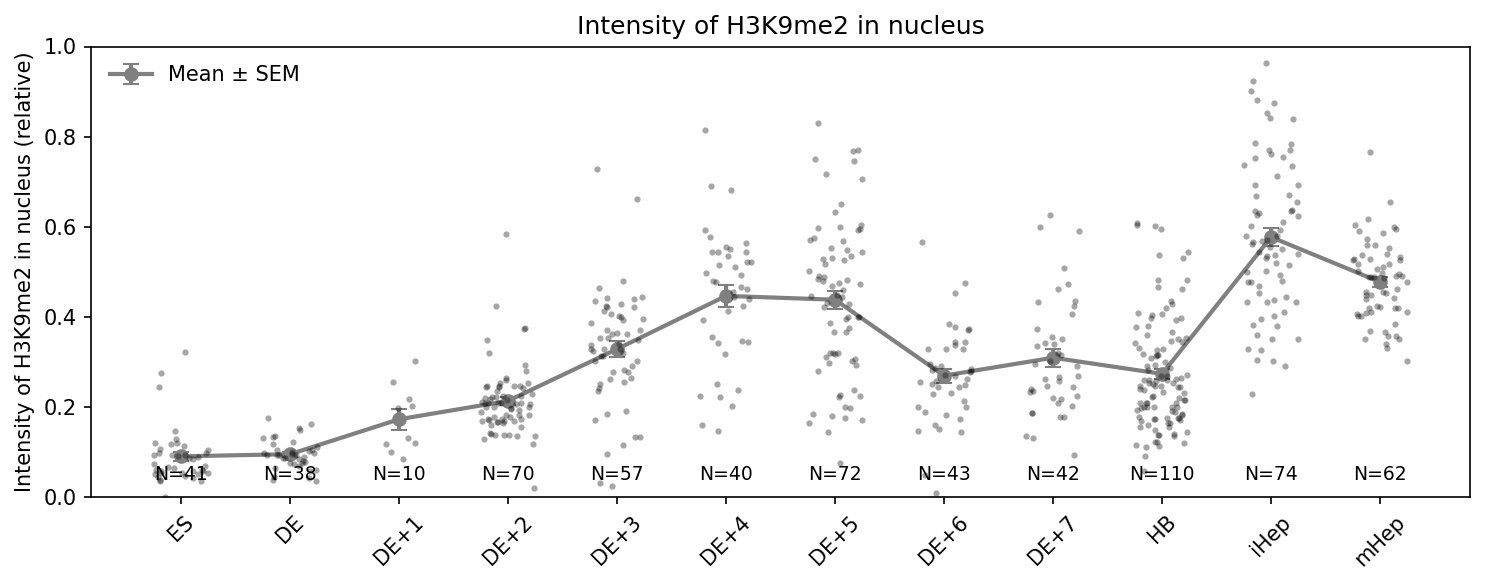

In [120]:
# -------------------------
# Prepare data
# -------------------------
df_me2_both2["h3k9me2_mean_intensity_rel"] = (
    df_me2_both2["nuclear_mean_intensity"] / 225.0
)

#timecourse_order = ["DE", "DE+1", "DE+2", "DE+3", "DE+4", "DE+5", "DE+6", "DE+7", "HB"]
timecourse_order = ["ES", "DE", "DE+1", "DE+2", "DE+3", "DE+4", "DE+5", "DE+6", "DE+7", "HB", "iHep","mHep"]


# make sure exclude_timecourses exists
# example:
# exclude_timecourses = ["H1", "HB+1", "HB+2", "iHep"]

df_me2_both_plot = df_me2_both2[
    ~df_me2_both2["timecourse"].isin(exclude_timecourses)
].copy()

df_me2_both_plot["timecourse"] = pd.Categorical(
    df_me2_both_plot["timecourse"],
    categories=timecourse_order,
    ordered=True
)

df_me2_both_plot = df_me2_both_plot.dropna(
    subset=["h3k9me2_mean_intensity_rel"]
)

# -------------------------
# Summary table
# -------------------------
summary_df = (
    df_me2_both_plot
    .groupby("timecourse", observed=False)
    .agg(
        mean_intensity=("h3k9me2_mean_intensity_rel", "mean"),
        median_intensity=("h3k9me2_mean_intensity_rel", "median"),
        sem_intensity=(
            "h3k9me2_mean_intensity_rel",
            lambda x: x.std(ddof=1) / np.sqrt(len(x))
        ),
        n=("h3k9me2_mean_intensity_rel", "size")
    )
    .reindex(timecourse_order)
    .reset_index()
)

summary_df["x"] = np.arange(len(summary_df))

# -------------------------
# Plot
# -------------------------
plt.figure(figsize=(10, 4), dpi=150)
ax = plt.gca()

# individual points
sns.stripplot(
    data=df_me2_both_plot,
    x="timecourse",
    y="h3k9me2_mean_intensity_rel",
    order=timecourse_order,
    color="black",
    size=3,
    jitter=0.25,
    alpha=0.35,
    ax=ax
)

# mean ± SEM line
ax.errorbar(
    summary_df["x"],
    summary_df["mean_intensity"],
    yerr=summary_df["sem_intensity"],
    marker="o",
    linewidth=2,
    capsize=4,
    color="gray",
    label="Mean ± SEM"
)

# -------------------------
# Add N labels
# -------------------------
for i, row in summary_df.iterrows():
    n = 0 if pd.isna(row["n"]) else int(row["n"])
    ax.text(
        i,
        0.03,
        f"N={n}",
        ha="center",
        va="bottom",
        fontsize=9
    )

ax.set_xticks(summary_df["x"])
ax.set_xticklabels(timecourse_order, rotation=45)

ax.set_ylabel("Intensity of H3K9me2 in nucleus (relative)")
ax.set_xlabel("")
ax.set_title("Intensity of H3K9me2 in nucleus")
ax.set_ylim(0, 1)

ax.legend(frameon=False)

plt.tight_layout()
plt.savefig(
    "/home/xiangru.huo-umw/scHiC/scripts/hardening_image/IF/Intensity_of_H3K9me2_in_nucleus_12timepoints_lineplot.pdf"
)
plt.show()

/home/xiangru.huo-umw/conda/Jupiter/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/home/xiangru.huo-umw/conda/Jupiter/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/home/xiangru.huo-umw/conda/Jupiter/lib/python3.11/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)


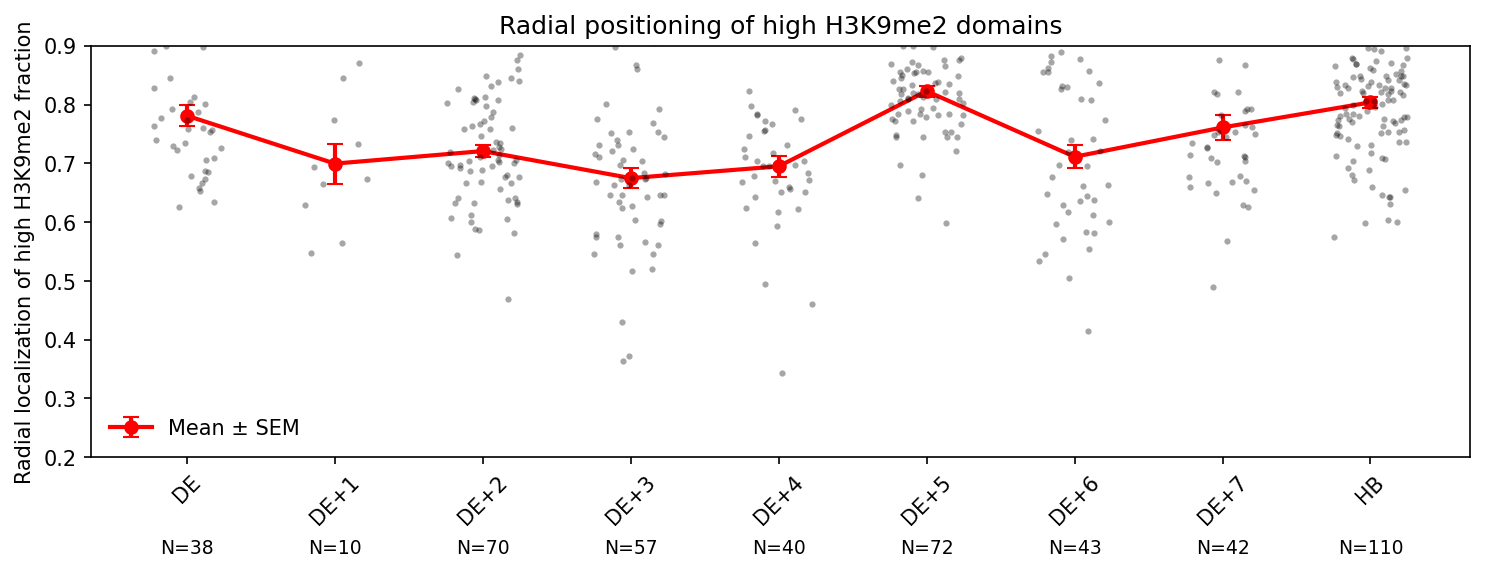

In [123]:
# -------------------------
# Prepare data
# -------------------------
exclude_timecourses = ["HB+1", "HB+2"]

df_me2_plot = df_me2_both2[
    ~df_me2_both2["timecourse"].isin(exclude_timecourses)
].copy()

timecourse_order = ["DE", "DE+1", "DE+2", "DE+3", "DE+4", "DE+5", "DE+6", "DE+7", "HB"]
#timecourse_order = ["ES", "DE", "DE+1", "DE+2", "DE+3", "DE+4", "DE+5", "DE+6", "DE+7", "HB", "iHep","mHep"]


df_me2_plot["timecourse"] = pd.Categorical(
    df_me2_plot["timecourse"],
    categories=timecourse_order,
    ordered=True
)

df_me2_plot = df_me2_plot.dropna(subset=["high_frac_localization"])

# -------------------------
# Summary table
# -------------------------
summary_df = (
    df_me2_plot
    .groupby("timecourse", observed=False)
    .agg(
        mean_loc=("high_frac_localization", "mean"),
        median_loc=("high_frac_localization", "median"),
        sem_loc=("high_frac_localization", lambda x: x.std(ddof=1) / np.sqrt(len(x))),
        n=("high_frac_localization", "size")
    )
    .reindex(timecourse_order)
    .reset_index()
)

summary_df["x"] = np.arange(len(summary_df))

# -------------------------
# Plot
# -------------------------
plt.figure(figsize=(10, 4), dpi=150)
ax = plt.gca()

# individual points
sns.stripplot(
    data=df_me2_plot,
    x="timecourse",
    y="high_frac_localization",
    order=timecourse_order,
    color="black",
    size=3,
    jitter=0.25,
    alpha=0.35,
    ax=ax
)

# mean ± SEM line
ax.errorbar(
    summary_df["x"],
    summary_df["mean_loc"],
    yerr=summary_df["sem_loc"],
    marker="o",
    linewidth=2,
    capsize=4,
    color="red",
    label="Mean ± SEM"
)

# -------------------------
# Add N labels
# -------------------------
for i, row in summary_df.iterrows():
    n = 0 if pd.isna(row["n"]) else int(row["n"])
    ax.text(
        i,
        0.03,
        f"N={n}",
        ha="center",
        va="bottom",
        fontsize=9
    )

ax.set_xticks(summary_df["x"])
ax.set_xticklabels(timecourse_order, rotation=45)

ax.set_ylabel("Radial localization of high H3K9me2 fraction")
ax.set_xlabel("")
ax.set_title("Radial positioning of high H3K9me2 domains")
ax.set_ylim(0.2, 0.9)

ax.legend(frameon=False)

plt.tight_layout()
plt.savefig(
    "/home/xiangru.huo-umw/scHiC/scripts/hardening_image/IF/Radial_positioning_of_H3K9me2_domains_in_nucleus_lineplot.pdf"
)
plt.show()